# NL IVP Comparison

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt
from IPython.display import clear_output
from process.main import SingleRun
from pathlib import Path
import process
from scipy.stats import qmc

Running scipy's SLSQP


In [2]:
%matplotlib inline
# Study set up
N = 10
# ne = np.linspace(6.0e19, 1.2e20, num=N)
# te = np.linspace(8.0, 14.0, num=N)
# Zoom in
ne = np.linspace(7.5e19, 1.1e20, num=N)
te = np.linspace(8.5, 12.0, num=N)
ne_grid, te_grid = np.meshgrid(ne, te)


def evaluate(
    ne,
    te,
    p_hcd_primary_extra_heat_mw,
    molflow_plasma_fuelling_required,
    triang,
    w_frac,
):
    # input_file = "int_err_eval_IN.DAT"
    # Changed to other failing case: previous case to reproduce original figures
    input_file = "failing_ivp_eval_IN.DAT"
    single_run = SingleRun(input_file)
    # Loading single run overwrites variables: set again
    process.data_structure.physics_variables.nd_plasma_electrons_vol_avg = ne
    process.data_structure.physics_variables.temp_plasma_electron_vol_avg_kev = te

    # If supplied, overwrite default values
    if (
        not np.isnan(p_hcd_primary_extra_heat_mw).all()
        and not np.isnan(molflow_plasma_fuelling_required).all()
    ):
        process.data_structure.current_drive_variables.p_hcd_primary_extra_heat_mw = (
            p_hcd_primary_extra_heat_mw
        )
        process.data_structure.physics_variables.molflow_plasma_fuelling_required = (
            molflow_plasma_fuelling_required
        )
    if not np.isnan(triang).all():
        process.data_structure.physics_variables.triang = triang
    if not np.isnan(w_frac).all():
        process.data_structure.impurity_radiation_module.f_nd_impurity_electron_array[
            13
        ] = w_frac

    try:
        # Handle failed runs
        single_run.run()
    except Exception as e:
        return np.nan, np.nan, np.nan, np.nan, np.nan, e

    return (
        # PPB
        process.constraints.constraint_equation_2().normalised_residual,
        # Fuel equilibrium
        process.constraints.constraint_equation_93().normalised_residual,
        # beta limit
        process.constraints.constraint_equation_24().normalised_residual,
        # Greenwald limit (check)
        process.constraints.constraint_equation_5().normalised_residual,
        # L-H threshold
        process.constraints.constraint_equation_15().normalised_residual,
        # Error
        None,
    )


def solve(
    ne_init=None,
    te_init=None,
    p_hcd_primary_extra_heat_mw=None,
    molflow_plasma_fuelling_required=None,
    triang=None,
    w_frac=None,
    integrate=False,
):
    if integrate:
        # input_file = "int_err_IN.DAT"
        input_file = "failing_ivp_IN.DAT"
    else:
        # input_file = "int_err_nlsol_IN.DAT"
        input_file = "failing_ivp_nlsol_IN.DAT"
    single_run = SingleRun(input_file)
    if p_hcd_primary_extra_heat_mw and molflow_plasma_fuelling_required:
        process.data_structure.current_drive_variables.p_hcd_primary_extra_heat_mw = (
            p_hcd_primary_extra_heat_mw
        )
        process.data_structure.physics_variables.molflow_plasma_fuelling_required = (
            molflow_plasma_fuelling_required
        )
    # Set initial parameter vector
    if ne_init and te_init:
        process.data_structure.physics_variables.nd_plasma_electrons_vol_avg = ne_init
        process.data_structure.physics_variables.temp_plasma_electron_vol_avg_kev = (
            te_init
        )

    # Set uncertainties
    if triang:
        process.data_structure.physics_variables.triang = triang
    if w_frac:
        process.data_structure.impurity_radiation_module.f_nd_impurity_electron_array[
            13
        ] = w_frac
    # Might fail
    single_run.run()


def plot(
    ppb,
    fuel_eq,
    beta_lim,
    gw_lim,
    lh_lim,
    iter_df,
    ivp_iter_df=None,
):
    fig, ax = plt.subplots()
    ax.set_title("NL-solved and IVP solutions to large tokamak")

    # Plot
    ax.set_xlabel("$n_e$")
    ax.set_ylabel("$T_e$")
    contours = []
    contours.append(
        ax.contour((ne_grid * 1e-19), te_grid, ppb, levels=[0.0], colors="C0")
    )
    contours.append(
        ax.contour(
            (ne_grid * 1e-19),
            te_grid,
            fuel_eq,
            levels=[0.0],
            colors="C1",
        )
    )

    # Stability constraints
    ALPHA = 0.15
    contours.append(
        ax.contourf(
            (ne_grid * 1e-19),
            te_grid,
            beta_lim,
            levels=[0.0, np.inf],
            colors="C2",
            alpha=ALPHA,
        )
    )
    contours.append(
        ax.contourf(
            (ne_grid * 1e-19),
            te_grid,
            gw_lim,
            levels=[0.0, np.inf],
            colors="C3",
            alpha=ALPHA,
        )
    )
    contours.append(
        ax.contourf(
            (ne_grid * 1e-19),
            te_grid,
            lh_lim,
            levels=[0.0, np.inf],
            colors="C4",
            alpha=ALPHA,
        )
    )

    names = []
    labels = []
    for contour in contours:
        name, label = contour.legend_elements()
        names.append(name[0])
        labels.append(label[0])
        # contour.collections

    # NL solver iterations
    legend1 = None
    if iter_df is not None:
        # Initial point
        ax.scatter(
            iter_df["ne"].values[0] * 1e-19,
            iter_df["te"].values[0],
            c="C2",
            marker="o",
            label="NL solver intial",
            edgecolors="black",
        )
        # Iterations
        ax.scatter(
            iter_df["ne"].values[1:-1] * 1e-19,
            iter_df["te"].values[1:-1],
            c="C2",
            marker=".",
            label="NL solver iterations",
            zorder=11,
        )
        # Make solution point different
        ax.scatter(
            iter_df["ne"].values[-1] * 1e-19,
            iter_df["te"].values[-1],
            c="C2",
            marker="X",
            label="NL solver final",
            edgecolors="black",
            zorder=100,
        )
        # cbar = fig.colorbar(scatter)
        # cbar.set_label("Solver iterations")
        # TODO Would be better not to hard-code, but tricky to combine multiple contour plots into single legend
        labels = ["PPB", "Fuel eq", r"$\beta$ lim", "Greenwald lim", "L-H lim"]
        legend1 = ax.legend(names, labels, bbox_to_anchor=(1.05, 1), loc="upper left")

    # Plot integration iterations
    if ivp_iter_df is not None:
        # Initial point
        ax.scatter(
            ivp_iter_df["ne"].values[0] * 1e-19,
            ivp_iter_df["te"].values[0],
            c="C3",
            marker="o",
            label="IVP initial",
            edgecolors="black",
        )
        # Iterations
        ax.scatter(
            ivp_iter_df["ne"].values[1:-1] * 1e-19,
            ivp_iter_df["te"].values[1:-1],
            c="C3",
            marker=".",
            label="IVP iterations",
        )
        # Highlight final point
        ax.scatter(
            ivp_iter_df["ne"].values[-1] * 1e-19,
            ivp_iter_df["te"].values[-1],
            c="C3",
            marker="X",
            label="IVP final",
            edgecolors="black",
            zorder=100,
        )
        ax.legend(bbox_to_anchor=(1.05, 0.5), loc="upper left")
        if legend1:
            ax.add_artist(legend1)

    return ax


def evaluate_all(
    p_hcd_primary_extra_heat_mw=None,
    molflow_plasma_fuelling_required=None,
    triang=None,
    w_frac=None,
):
    eval_n_alpha_vec = np.vectorize(pyfunc=evaluate)
    ppb, fuel_eq, beta_lim, gw_lim, lh_lim, e = eval_n_alpha_vec(
        ne_grid,
        te_grid,
        np.full_like(ne_grid, fill_value=p_hcd_primary_extra_heat_mw),
        np.full_like(ne_grid, fill_value=molflow_plasma_fuelling_required),
        np.full_like(ne_grid, fill_value=triang),
        np.full_like(ne_grid, fill_value=w_frac),
    )
    return ppb, fuel_eq, beta_lim, gw_lim, lh_lim, e


def eval_solve_plot(
    ne_init=None,
    te_init=None,
    p_hcd_primary_extra_heat_mw=None,
    molflow_plasma_fuelling_required=None,
    triang=None,
    w_frac=None,
):
    EVALUATIONS_PATH = "evaluations.csv"
    print("Evaluating")
    # Evaluate all points
    ppb, fuel_eq, beta_lim, gw_lim, lh_lim, e = evaluate_all(
        p_hcd_primary_extra_heat_mw=p_hcd_primary_extra_heat_mw,
        molflow_plasma_fuelling_required=molflow_plasma_fuelling_required,
        triang=triang,
        w_frac=w_frac,
    )
    clear_output()
    evals_df = make_df(ppb, fuel_eq, beta_lim, gw_lim, lh_lim, e)
    evals_df.to_csv(EVALUATIONS_PATH)

    # Solve
    print("Running NL solver")
    try:
        solve(
            ne_init=ne_init,
            te_init=te_init,
            p_hcd_primary_extra_heat_mw=p_hcd_primary_extra_heat_mw,
            molflow_plasma_fuelling_required=molflow_plasma_fuelling_required,
            triang=triang,
            w_frac=w_frac,
        )
        clear_output()
        iter_df = pd.read_csv("iterations.csv")
    except:
        clear_output()
        iter_df = None

    print("Running IVP solver")
    # Integrate
    try:
        solve(
            ne_init=ne_init,
            te_init=te_init,
            p_hcd_primary_extra_heat_mw=p_hcd_primary_extra_heat_mw,
            molflow_plasma_fuelling_required=molflow_plasma_fuelling_required,
            triang=triang,
            w_frac=w_frac,
            integrate=True,
        )
        clear_output()
        print("IVP successful")
        ivp_iter_df = pd.read_csv("ivp_iterations.csv")
    except Exception as err:
        clear_output()
        print(f"IVP failed: {err}")
        # Always produced even if solve_ivp fails: stored before model evaluations
        ivp_iter_df = pd.read_csv("pre_ivp_evaluations.csv")

    # Plot both
    ax = plot(
        ppb=ppb,
        fuel_eq=fuel_eq,
        beta_lim=beta_lim,
        gw_lim=gw_lim,
        lh_lim=lh_lim,
        iter_df=iter_df,
        ivp_iter_df=ivp_iter_df,
    )
    return evals_df, iter_df, ivp_iter_df, ax


def make_df(ppb, fuel_eq, beta_lim, gw_lim, lh_lim, e):
    return pd.DataFrame(
        {
            "ne": ne_grid.flatten(),
            "te": te_grid.flatten(),
            "ppb": ppb.flatten(),
            "fuel_eq": fuel_eq.flatten(),
            "beta_lim": beta_lim.flatten(),
            "gw_lim": gw_lim.flatten(),
            "lh_lim": lh_lim.flatten(),
            "error": e.flatten(),
        }
    )


def plot_ivp(ivp_iter_df):
    # Plot
    fig, ax = plt.subplots()
    line1 = ax.plot(ivp_iter_df["t"], ivp_iter_df["te"], label="$T_e$")
    ax.set_xlabel("$t$ $(s)$")
    ax.set_ylabel("$T_e$ $(keV)$")
    ax.ticklabel_format(axis="y", useOffset=False)
    ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
    ax2 = ax.twinx()
    line2 = ax2.plot(ivp_iter_df["t"], ivp_iter_df["ne"], color="C1", label="$n_e$")
    ax2.set_ylabel("$n_e$ $(m^{-3})$")
    ax2.ticklabel_format(axis="y", useOffset=False)
    lns = line1 + line2
    labs = [l.get_label() for l in lns]
    ax.legend(lns, labs, loc=0)
    ax.set_title("Integration of $dT_e/dt$ and $dn_e/dt$")


IVP successful


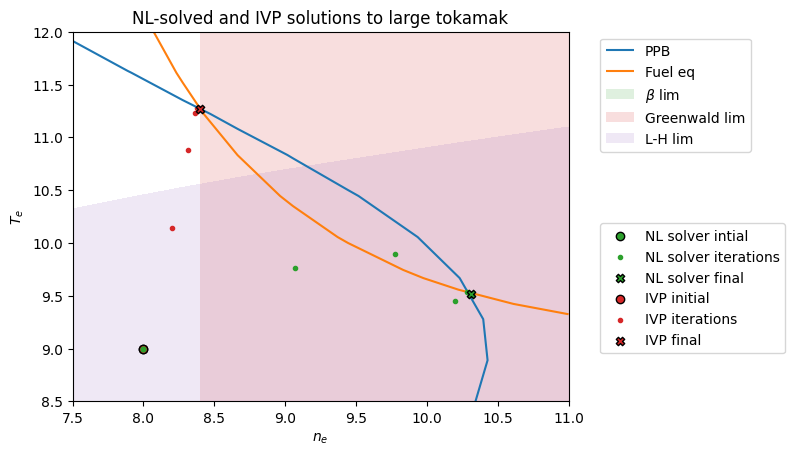

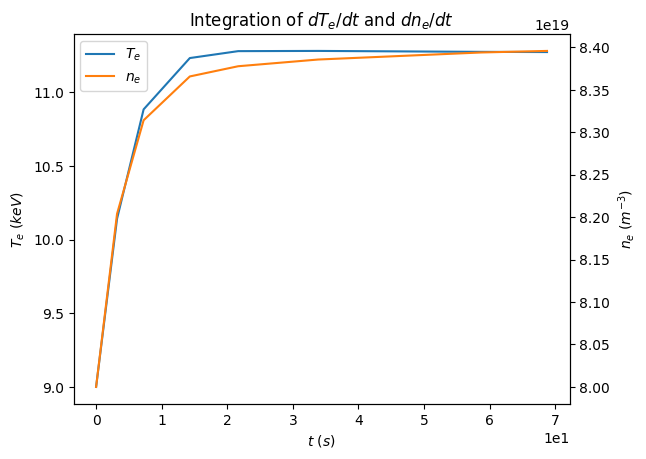

In [3]:
df, iter_df, ivp_iter_df, ax = eval_solve_plot(
    ne_init=8.0e19, te_init=9.0, w_frac=5.0e-6, triang=0.5
)
plot_ivp(ivp_iter_df)

IVP successful


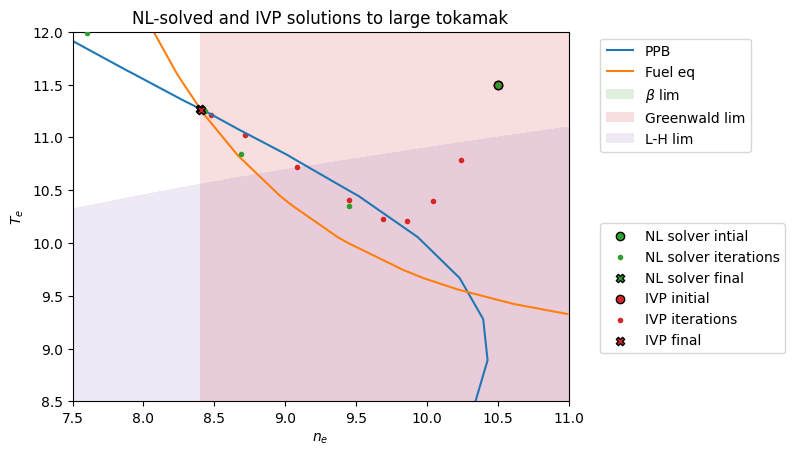

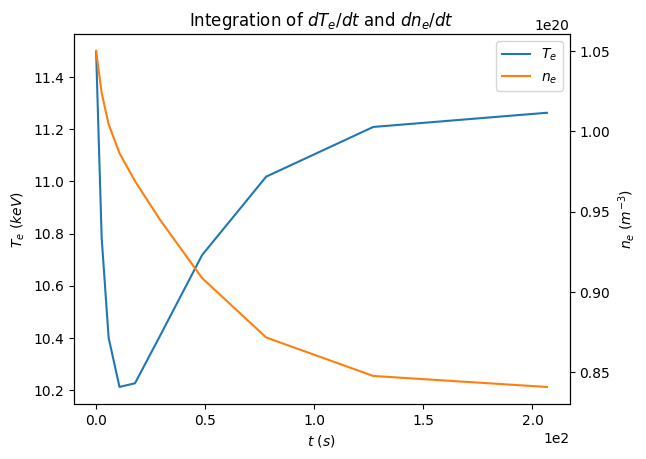

In [4]:
df2, iter_df2, ivp_iter_df2, ax2 = eval_solve_plot(
    ne_init=1.05e20, te_init=11.5, w_frac=5.0e-6, triang=0.5
)
plot_ivp(ivp_iter_df2)

IVP successful


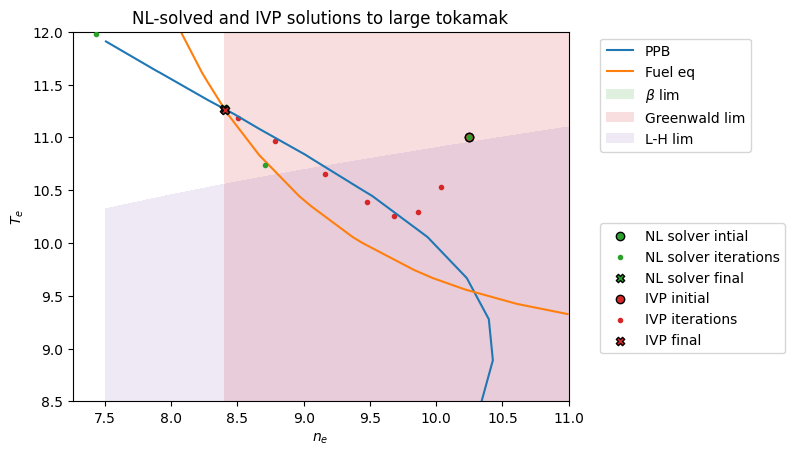

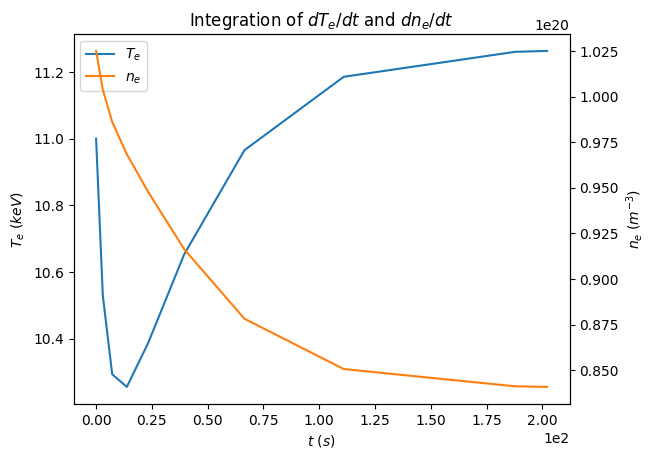

In [5]:
df3, iter_df3, ivp_iter_df3, ax3 = eval_solve_plot(
    ne_init=1.025e20, te_init=11.0, w_frac=5.0e-6, triang=0.5
)
plot_ivp(ivp_iter_df3)

IVP successful


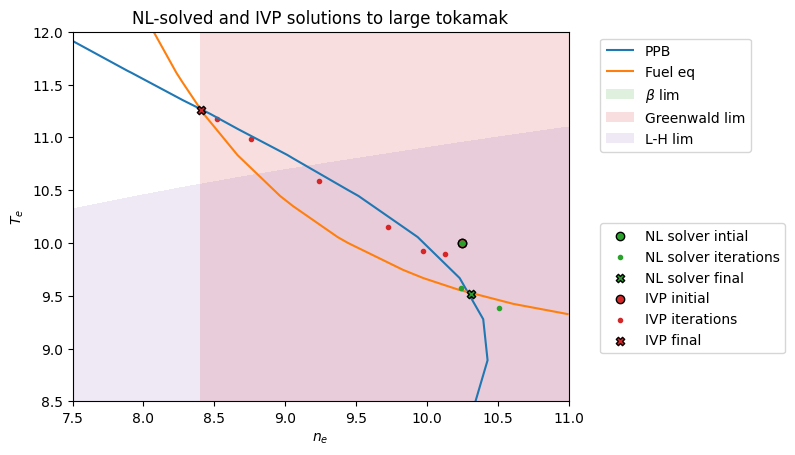

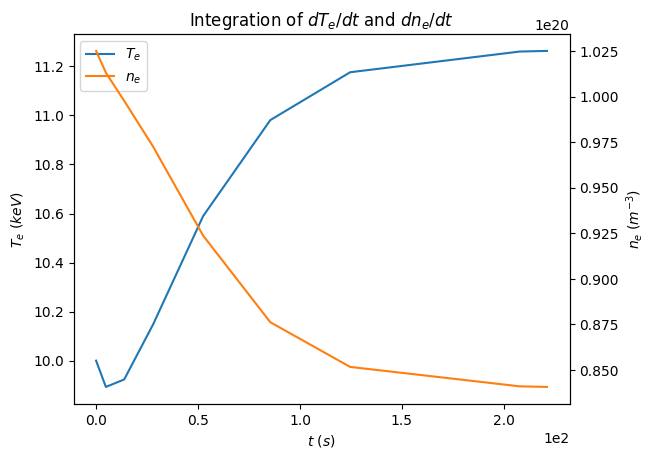

In [6]:
df6, iter_df6, ivp_iter_df6, ax6 = eval_solve_plot(
    ne_init=1.025e20, te_init=10.0, w_frac=5.0e-6, triang=0.5
)
plot_ivp(ivp_iter_df6)

IVP successful


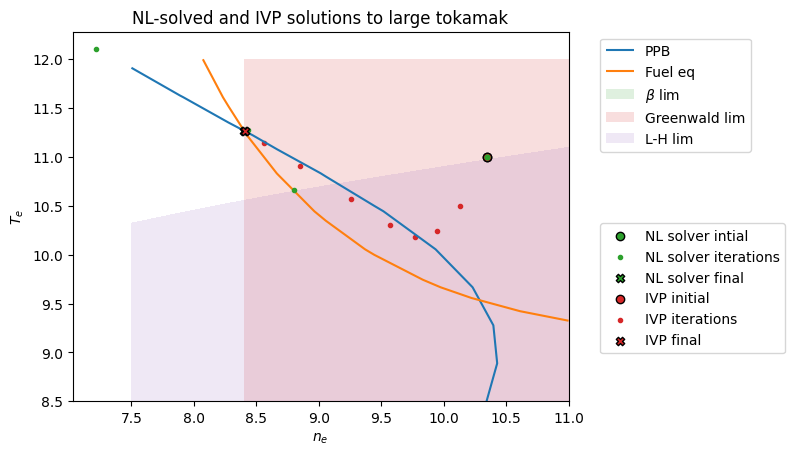

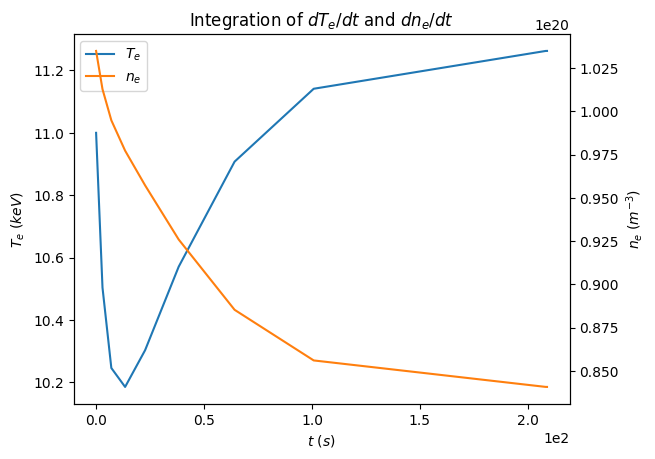

In [7]:
df5, iter_df5, ivp_iter_df5, ax5 = eval_solve_plot(
    ne_init=1.035e20, te_init=11.0, w_frac=5.0e-6, triang=0.5
)
plot_ivp(ivp_iter_df5)

IVP successful


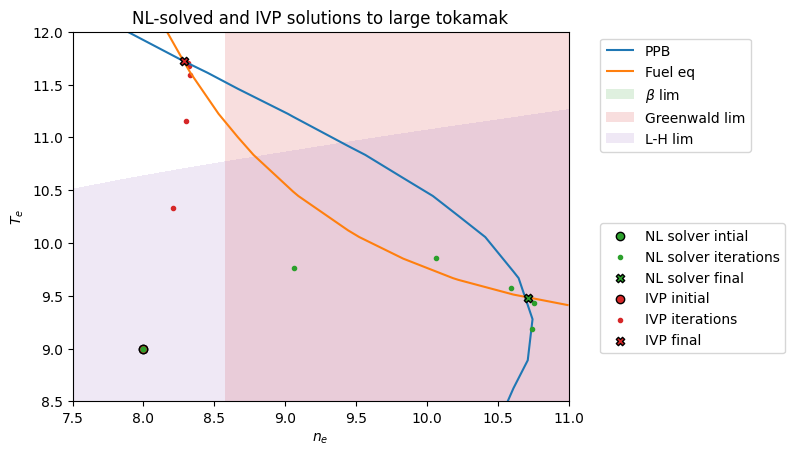

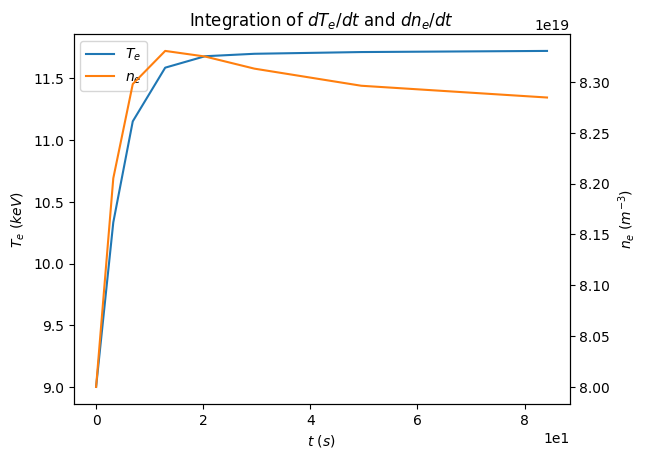

In [8]:
df4, iter_df4, ivp_iter_df4, ax4 = eval_solve_plot(
    ne_init=8.0e19, te_init=9.0, w_frac=1.0e-5, triang=0.55
)
plot_ivp(ivp_iter_df4)

Try a failing IVP case.

IVP failed: znfuel is negative


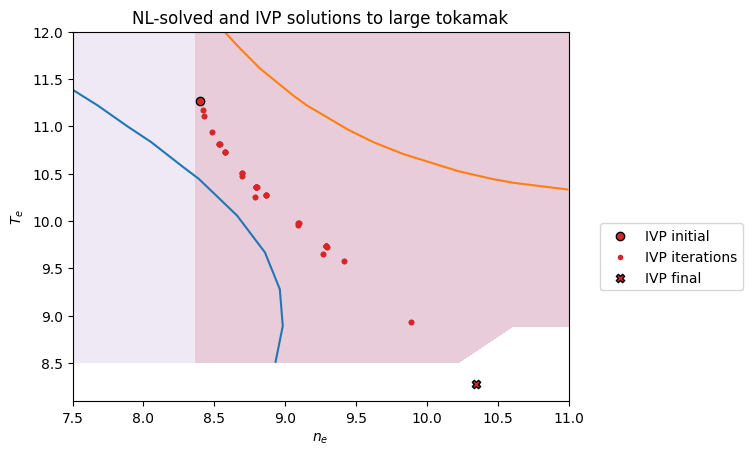

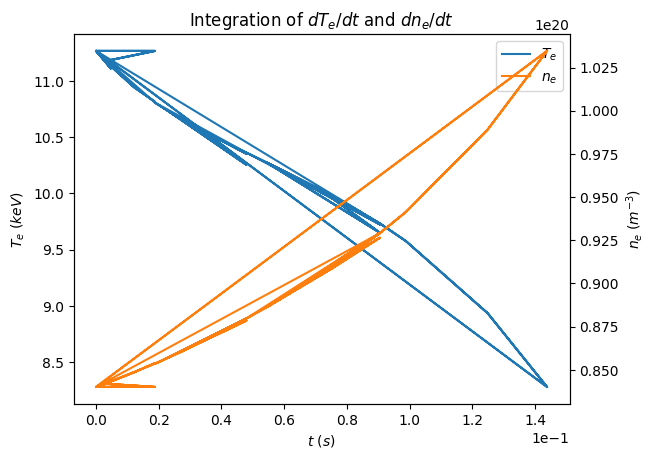

In [4]:
df7, iter_df7, ivp_iter_df7, ax7 = eval_solve_plot(
    w_frac=6.591437250812121e-05, triang=0.4908377792785496
)
plot_ivp(ivp_iter_df7)

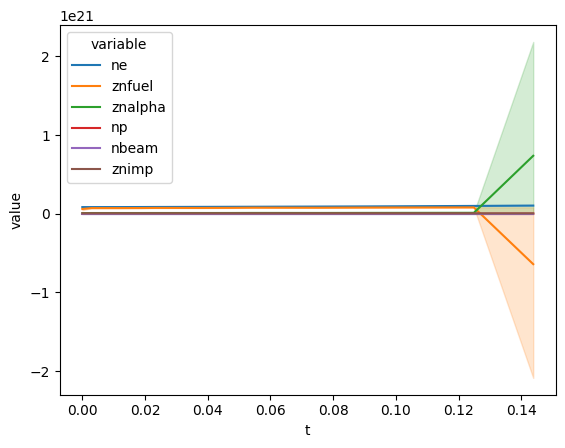

In [ ]:
%matplotlib inline
ivp_iter_df7_dropped = ivp_iter_df7.drop(labels=["te"], axis=1)
ivp_iter_df7_melt = ivp_iter_df7_dropped.melt(id_vars="t")
ax = sns.lineplot(data=ivp_iter_df7_melt, x="t", y="value", hue="variable")
# ax.set_yscale("log")

Values before error appear stable. Negative znfuel is real: sudden large increase in nalpha (2 OOM).